## (Exercise) Imputation of tips

Consider the `taxis` dataset from seaborn, practice the imputation methods on the `tip` column for the dataset `subtaxi_missing`, given below:

1. Complete the data using         
    i. mean simple imputation,
    ii. median simple imputation,
    iii. k-nearest neighbor, and
    iv. predictive mean matching.
2. Compute the root mean squared error for each imputation method (because you know the truth).  Which one is the best in this case?
3. Examine the correlation matrix among the numerical columns.  Which methods preserve the correlation among variables?

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
import miceforest as mf
from sklearn.metrics import mean_squared_error
import math

In [59]:
taxi = sns.load_dataset('taxis')
taxi.info()
subtaxi = taxi.loc[:, ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']]

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [60]:
# create missingness
np.random.seed(42)
mask1 = subtaxi.total > 25
mask2 = np.random.rand(subtaxi.shape[0]) < 0.7

subtaxi_missing = subtaxi.copy()
subtaxi_missing.loc[mask1 & mask2, 'tip'] = np.nan

<Axes: >

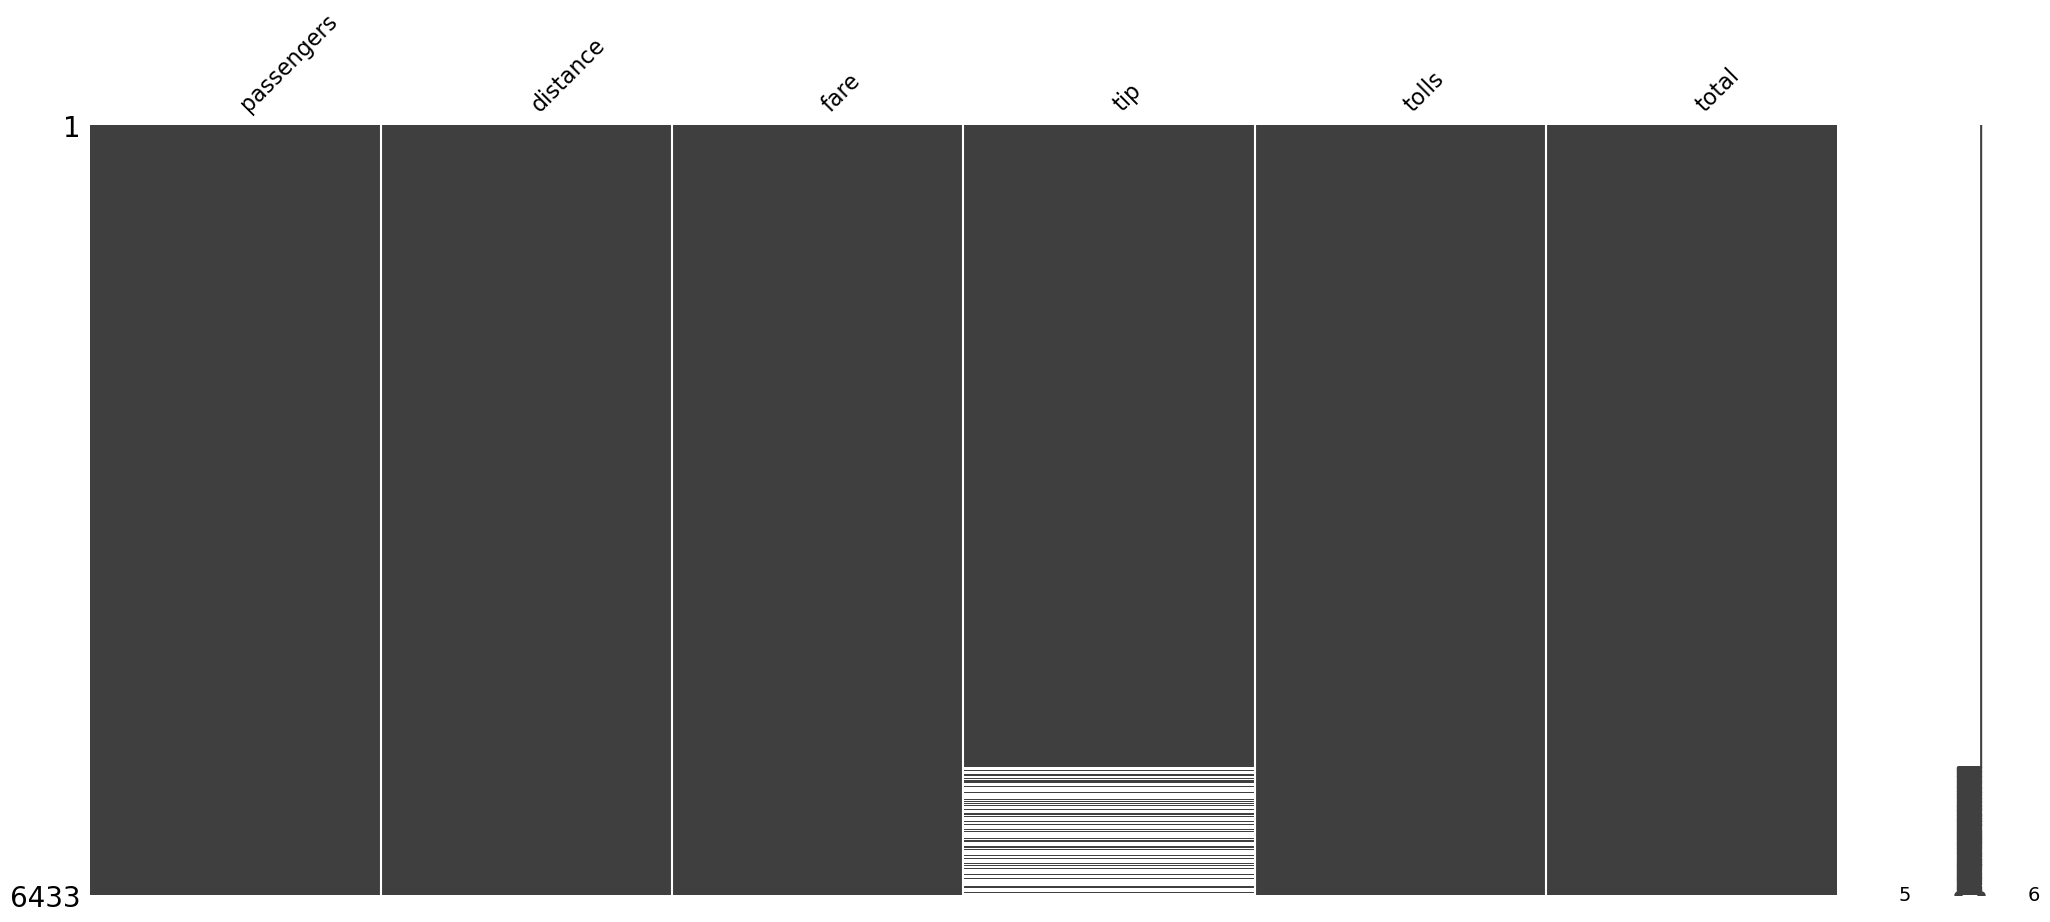

In [61]:
msno.matrix(subtaxi_missing.sort_values('total'))

## Imputations

### Mean simple imputation

In [62]:
# MEAN SIMPLE IMPUTATION
mean_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
subtaxi_mean = subtaxi_missing.copy()
subtaxi_mean['tip'] = mean_imputer.fit_transform(subtaxi_missing[['tip']])

<Axes: xlabel='tip', ylabel='Count'>

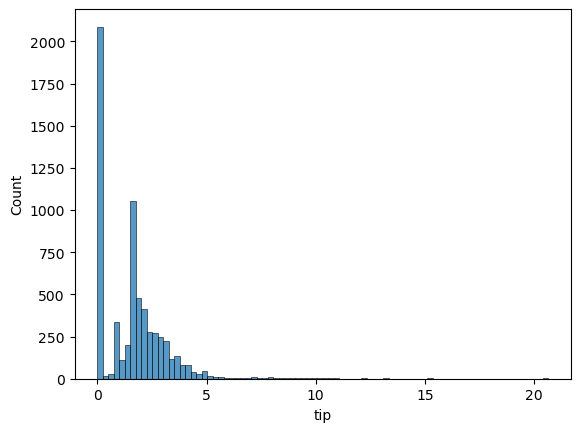

In [63]:
sns.histplot(subtaxi_mean['tip'])

### Median simple imputation

In [64]:
# MEDIAN SIMPLE IMPUTATION
median_imputer = SimpleImputer(missing_values=np.nan, strategy='median')
subtaxi_median = subtaxi_missing.copy()
subtaxi_median['tip'] = median_imputer.fit_transform(subtaxi_missing[['tip']])

<Axes: xlabel='tip', ylabel='Count'>

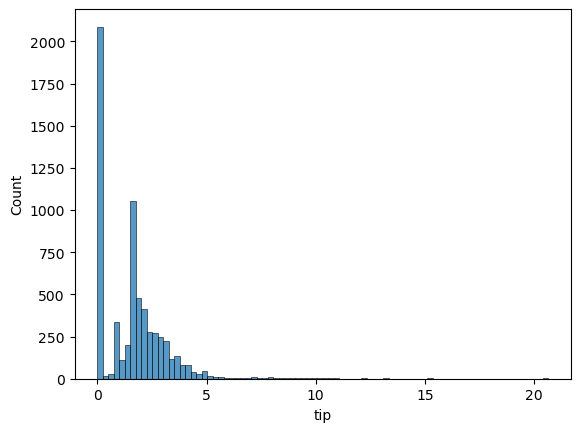

In [65]:
sns.histplot(subtaxi_median['tip'])

### KNN imputation

In [66]:
# KNN IMPUTATION
subtaxi_knn = subtaxi_missing.copy()
knn_imputer = KNNImputer(n_neighbors=5)
subtaxi_knn['tip'] = knn_imputer.fit_transform(subtaxi_missing[['tip']])

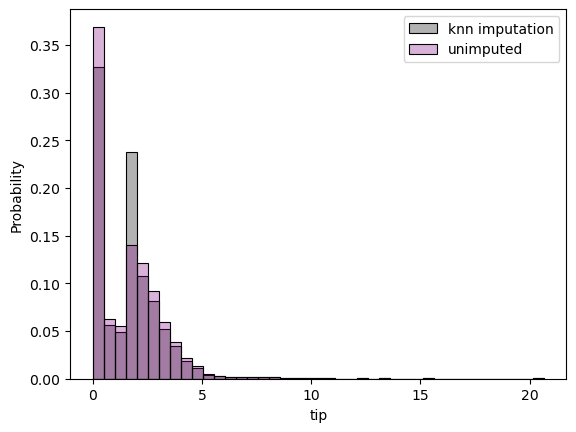

In [67]:
fig, ax = plt.subplots(1, 1)
sns.histplot(subtaxi_knn['tip'], binwidth=0.5, stat='probability', alpha=0.3, color='k', label='knn imputation')
sns.histplot(subtaxi_missing['tip'], binwidth=0.5, stat='probability', alpha=0.3, color='purple', label='unimputed')
ax.legend()

### Predictive mean matching

In [68]:
# PREDICTIVE MEAN MATCHING
num_datasets = 4
kernel_pmm = mf.ImputationKernel(
    data=subtaxi_missing.select_dtypes('number'),
    num_datasets=num_datasets,
    mean_match_candidates=5,
    save_all_iterations_data=False,
    random_state=1
)

In [69]:
kernel_pmm.mice(iterations=5)

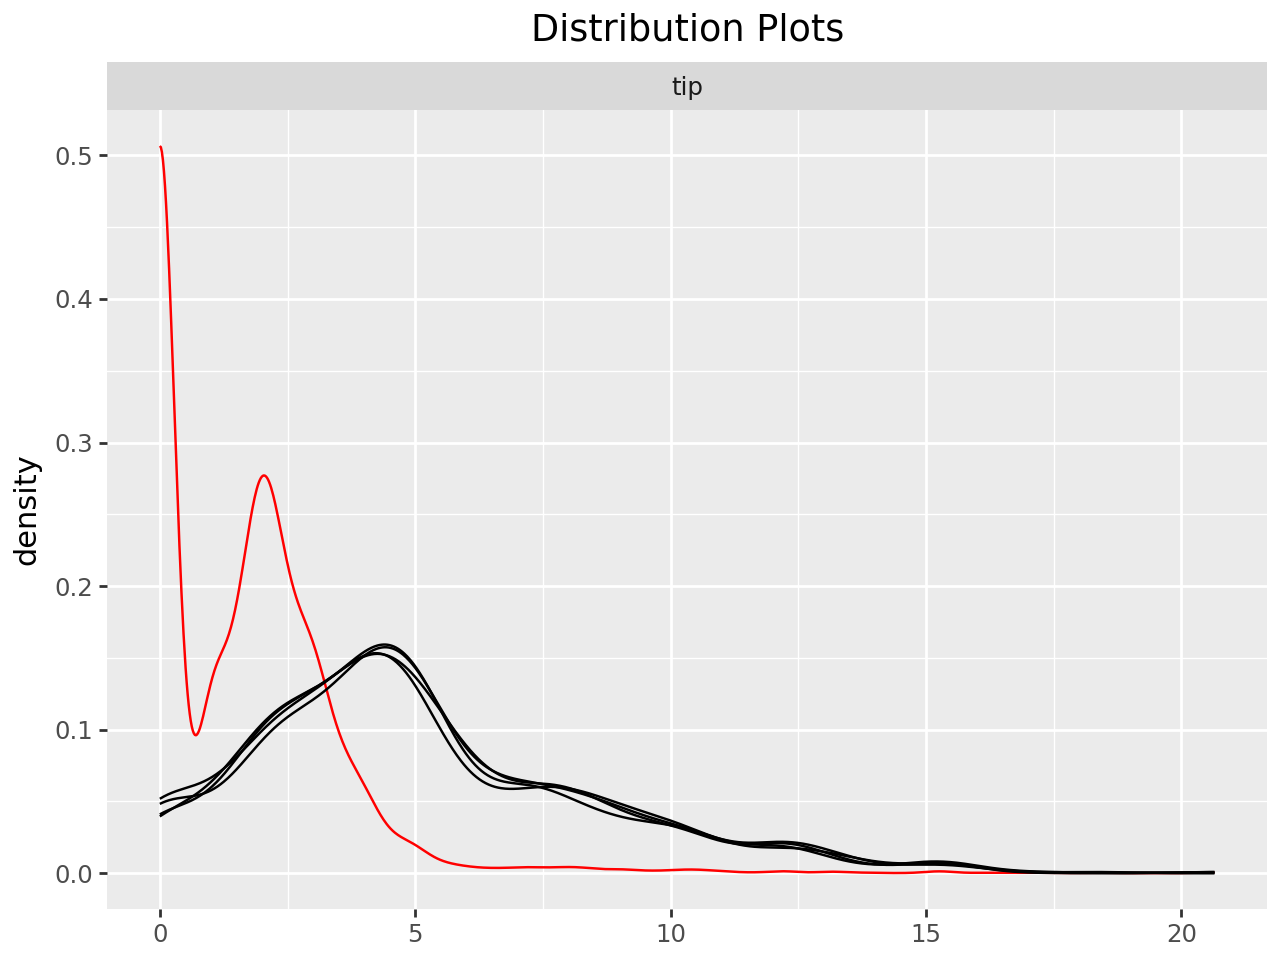

In [70]:
kernel_pmm.plot_imputed_distributions()

In [71]:
kernel_pmm.tune_parameters()
tip_pmm = kernel_pmm.complete_data

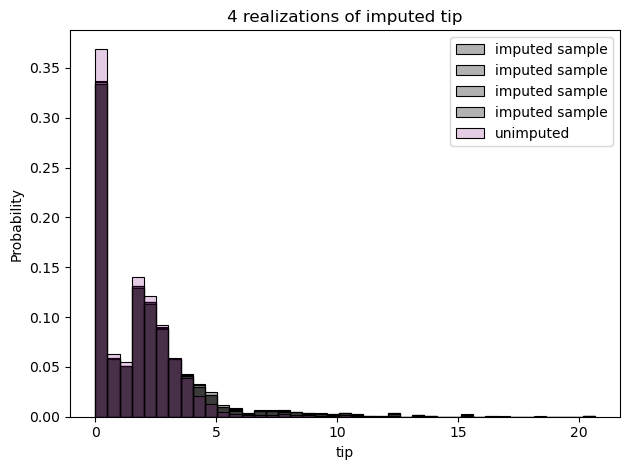

In [72]:
for k in range(num_datasets):
    sns.histplot(tip_pmm(dataset=k)['tip'], binwidth=0.5, stat='probability', alpha=0.3, label='imputed sample', color='k')
sns.histplot(subtaxi_missing['tip'], binwidth=0.5, stat='probability', alpha=0.2, label='unimputed', color='purple')

plt.title('{:d} realizations of imputed tip'.format(num_datasets))
plt.legend()
plt.tight_layout()
plt.show()

## RMSE for each imputation method

In [73]:
# SIMPLE MEAN IMPUTATION RMSE
mean_rmse = math.sqrt(mean_squared_error(subtaxi['tip'], subtaxi_mean['tip']))
mean_rmse

1.7890890417337866

In [74]:
# SIMPLE MEDIAN IMPUTATION RMSE
median_rmse = math.sqrt(mean_squared_error(subtaxi['tip'], subtaxi_median['tip']))
median_rmse

1.803864708744896

In [75]:
# KNN IMPUTATION RMSE
knn_rmse = math.sqrt(mean_squared_error(subtaxi['tip'], subtaxi_knn['tip']))
knn_rmse

1.7890890417337866

In [76]:
# PREDICTIVE MEAN MATCHING RMSE
pmm_rmse = math.sqrt(mean_squared_error(subtaxi['tip'], tip_pmm(dataset=0)['tip']))
pmm_rmse

0.9105758654023257

Since the predictive mean matching method has the lowest RMSE of 0.911, we conclude that it's the best approach in this case.